## Assumptions
- 2024 lab report did not include sample depth — depth inferred from report context
- 2025 samples were taken later in the season (October) vs. 2024 (June)
- Samples were not necessarily taken at the same location each year
- Chlorophyll-a was only measured in 2025, limiting direct year-over-year comparison

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Clone the repo to access sample result CSVs
!git clone https://github.com/GreenVaultJoe/capstone_Chrysler_Pond.git

base = "capstone_Chrysler_Pond/Sample Results"


fatal: destination path 'capstone_Chrysler_Pond' already exists and is not an empty directory.


In [ ]:
# Load lab sample CSVs for each year
df24 = pd.read_csv(f"{base}/2024/2024_Sample_Results.csv")
df25 = pd.read_csv(f"{base}/2025/2025_Sample_Results.csv")

df24.head()
# df25.head()

,Date,Client Sample ID,Matrix,Parameter,Value,Units
0,6/10/2024,EMF - Water,WATER,"Nitrate, Nitrogen (As N)",ND,mg/L
1,6/10/2024,EMF - Water,WATER,Escherichia Coli,1.0,MPN/100mL
2,6/10/2024,EMF - Water,WATER,"Nitrogen, Ammonia (As N)",ND,mg/L
3,6/10/2024,EMF - Water,WATER,Total Phosphorus (as P),0.06,mg/L
4,6/10/2024,EMF - Water,WATER,"Nitrogen, Kjeldahl, Total",ND,mg/L


In [ ]:
df25.tail()

,Sampling Date,Sample Label,Depth (ft),Parameter,Value,Units
7,10/01/2025,Deep Sample,7,Conductivity,466.5,µS/cm
8,10/01/2025,Deep Sample,7,Free Reactive Phosphorus,6.6,µg/L
9,10/01/2025,Deep Sample,7,Chlorophyll a,33.4,µg/L
10,10/01/2025,Deep Sample,7,Total Phosphorus,380,µg/L
11,10/01/2025,Deep Sample,7,Total Nitrogen,9.66,mg/L


In [ ]:
# Standardize 2025: convert µg/L rows to mg/L for consistency with 2024
ug = df25["Units"].astype(str).str.replace("μ", "u").str.lower().eq("ug/l")
df25.loc[ug, "Value"] = pd.to_numeric(df25.loc[ug, "Value"], errors="coerce") / 1000
df25.loc[ug, "Units"] = "mg/L"
df25.tail()

,Sampling Date,Sample Label,Depth (ft),Parameter,Value,Units
7,10/01/2025,Deep Sample,7,Conductivity,466.5,µS/cm
8,10/01/2025,Deep Sample,7,Free Reactive Phosphorus,6.6,µg/L
9,10/01/2025,Deep Sample,7,Chlorophyll a,33.4,µg/L
10,10/01/2025,Deep Sample,7,Total Phosphorus,380,µg/L
11,10/01/2025,Deep Sample,7,Total Nitrogen,9.66,mg/L


In [ ]:
# Add Year and Zone labels to both datasets
df24["Year"] = 2024
df25["Year"] = 2025

df24["Zone"] = df24["Client Sample ID"].map(lambda s: "Near Device" if "EMF" in str(s) else ("Pond Center" if "Center" in str(s) else "Other"))
df25["Zone"] = df25["Sample Label"].map({"Shallow Sample": "Near Device", "Deep Sample": "Pond Center"}).fillna("Other")

df24.head()

,Date,Client Sample ID,Matrix,Parameter,Value,Units,Year,Zone
0,6/10/2024,EMF - Water,WATER,"Nitrate, Nitrogen (As N)",ND,mg/L,2024,Near Device
1,6/10/2024,EMF - Water,WATER,Escherichia Coli,1.0,MPN/100mL,2024,Near Device
2,6/10/2024,EMF - Water,WATER,"Nitrogen, Ammonia (As N)",ND,mg/L,2024,Near Device
3,6/10/2024,EMF - Water,WATER,Total Phosphorus (as P),0.06,mg/L,2024,Near Device
4,6/10/2024,EMF - Water,WATER,"Nitrogen, Kjeldahl, Total",ND,mg/L,2024,Near Device


In [ ]:
df25.head()

,Sampling Date,Sample Label,Depth (ft),Parameter,Value,Units,Year,Zone
0,10/01/2025,Shallow Sample,5,Turbidity,3.5,NTU,2025,Near Device
1,10/01/2025,Shallow Sample,5,Conductivity,298.8,µS/cm,2025,Near Device
2,10/01/2025,Shallow Sample,5,Free Reactive Phosphorus,6.1,µg/L,2025,Near Device
3,10/01/2025,Shallow Sample,5,Chlorophyll a,<10,µg/L,2025,Near Device
4,10/01/2025,Shallow Sample,5,Total Phosphorus,14.8,µg/L,2025,Near Device


In [ ]:
# Assign depth to 2024 rows based on matrix type and sample location
# Assumption: depth inferred from report context since 2024 report did not include depth
depth_conditions = [
    (df24['Matrix'] == "WATER"),
    (df24['Matrix'] == "SLUDGE") & (df24['Client Sample ID'].str.contains("Sludge Top", na=False)),
    (df24['Matrix'] == "SLUDGE") & (df24['Client Sample ID'].str.contains("Sludge Bottom", na=False))
]

depth_values = [5, 7, 10]

df24['Depth (ft)'] = np.select(depth_conditions, depth_values, default=None)

df24.tail()

,Date,Client Sample ID,Matrix,Parameter,Value,Units,Year,Zone,Depth (ft)
31,6/10/2024,Center - Sludge Bottom,SLUDGE,"Nitrogen, Nitrate (As N)",ND,µg/g-dry,2024,Pond Center,10
32,6/10/2024,Center - Sludge Bottom,SLUDGE,"Nitrogen, Ammonia (as N)",ND,µg/g-dry,2024,Pond Center,10
33,6/10/2024,Center - Sludge Bottom,SLUDGE,Percent Moisture,90.8,wt%,2024,Pond Center,10
34,6/10/2024,Center - Sludge Bottom,SLUDGE,Total Phosphorus (as P),309,µg/g-dry,2024,Pond Center,10
35,6/10/2024,Center - Sludge Bottom,SLUDGE,Total Kjeldahl Nitrogen as N,19900,µg/g-dry,2024,Pond Center,10


In [ ]:
df25.tail()

,Sampling Date,Sample Label,Depth (ft),Parameter,Value,Units,Year,Zone
7,10/01/2025,Deep Sample,7,Conductivity,466.5,µS/cm,2025,Pond Center
8,10/01/2025,Deep Sample,7,Free Reactive Phosphorus,6.6,µg/L,2025,Pond Center
9,10/01/2025,Deep Sample,7,Chlorophyll a,33.4,µg/L,2025,Pond Center
10,10/01/2025,Deep Sample,7,Total Phosphorus,380,µg/L,2025,Pond Center
11,10/01/2025,Deep Sample,7,Total Nitrogen,9.66,mg/L,2025,Pond Center


In [ ]:
# Align column names between 2024 and 2025 before merging
df24.rename(columns={'Date': 'Sampling Date'}, inplace=True)
df24.rename(columns={'Client Sample ID': 'Sample Label'}, inplace=True)

# Infer Matrix for 2025 from depth (>5ft = sludge)
df25['Matrix'] = np.where(df25['Depth (ft)'] > 5, 'SLUDGE', 'WATER')

print(df24.columns)
print(df25.columns)

Index(['Sampling Date', 'Sample Label', 'Matrix', 'Parameter', 'Value',
       'Units', 'Year', 'Zone', 'Depth (ft)'],
      dtype='object')
Index(['Sampling Date', 'Sample Label', 'Depth (ft)', 'Parameter', 'Value',
       'Units', 'Year', 'Zone', 'Matrix'],
      dtype='object')


In [ ]:
# Merge
combined = pd.concat([df24, df25], ignore_index=True)

display(combined)

,Sampling Date,Sample Label,Matrix,Parameter,Value,Units,Year,Zone,Depth (ft)
0,6/10/2024,EMF - Water,WATER,"Nitrate, Nitrogen (As N)",ND,mg/L,2024,Near Device,5
1,6/10/2024,EMF - Water,WATER,Escherichia Coli,1.0,MPN/100mL,2024,Near Device,5
2,6/10/2024,EMF - Water,WATER,"Nitrogen, Ammonia (As N)",ND,mg/L,2024,Near Device,5
3,6/10/2024,EMF - Water,WATER,Total Phosphorus (as P),0.06,mg/L,2024,Near Device,5
4,6/10/2024,EMF - Water,WATER,"Nitrogen, Kjeldahl, Total",ND,mg/L,2024,Near Device,5
5,6/10/2024,EMF - Water,WATER,Nitrite Nitrogen (as N),ND,mg/L,2024,Near Device,5
6,6/10/2024,EMF - Sludge Top,SLUDGE,"Nitrogen, Nitrite",ND,µg/g-dry,2024,Near Device,7
7,6/10/2024,EMF - Sludge Top,SLUDGE,"Nitrogen, Nitrate (As N)",ND,µg/g-dry,2024,Near Device,7
8,6/10/2024,EMF - Sludge Top,SLUDGE,"Nitrogen, Ammonia (as N)",ND,µg/g-dry,2024,Near Device,7
9,6/10/2024,EMF - Sludge Top,SLUDGE,Percent Moisture,95.4,wt%,2024,Near Device,7


In [ ]:
# Reorder columns
cols = ['Year','Sampling Date', 'Zone', 'Sample Label', 'Matrix', 'Depth (ft)', 'Parameter', 'Value', 'Units' ]

combined = combined[cols]

display(combined.tail())

,Year,Sampling Date,Zone,Sample Label,Matrix,Depth (ft),Parameter,Value,Units
43,2025,10/01/2025,Pond Center,Deep Sample,SLUDGE,7,Conductivity,466.5,µS/cm
44,2025,10/01/2025,Pond Center,Deep Sample,SLUDGE,7,Free Reactive Phosphorus,6.6,µg/L
45,2025,10/01/2025,Pond Center,Deep Sample,SLUDGE,7,Chlorophyll a,33.4,µg/L
46,2025,10/01/2025,Pond Center,Deep Sample,SLUDGE,7,Total Phosphorus,380,µg/L
47,2025,10/01/2025,Pond Center,Deep Sample,SLUDGE,7,Total Nitrogen,9.66,mg/L


In [ ]:
# Inspect phosphorus rows across both years
combined[combined["Parameter"].astype(str).str.lower().str.contains("phosphorus")]


,Year,Sampling Date,Zone,Sample Label,Matrix,Depth (ft),Parameter,Value,Units
3,2024,6/10/2024,Near Device,EMF - Water,WATER,5,Total Phosphorus (as P),0.06,mg/L
10,2024,6/10/2024,Near Device,EMF - Sludge Top,SLUDGE,7,Total Phosphorus (as P),942,µg/g-dry
16,2024,6/10/2024,Near Device,EMF - Sludge Bottom,SLUDGE,10,Total Phosphorus (as P),299,µg/g-dry
21,2024,6/10/2024,Pond Center,Center - Water,WATER,5,Total Phosphorus (as P),0.08,mg/L
28,2024,6/10/2024,Pond Center,Center - Sludge Top,SLUDGE,7,Total Phosphorus (as P),626,µg/g-dry
34,2024,6/10/2024,Pond Center,Center - Sludge Bottom,SLUDGE,10,Total Phosphorus (as P),309,µg/g-dry
38,2025,10/01/2025,Near Device,Shallow Sample,WATER,5,Free Reactive Phosphorus,6.1,µg/L
40,2025,10/01/2025,Near Device,Shallow Sample,WATER,5,Total Phosphorus,14.8,µg/L
44,2025,10/01/2025,Pond Center,Deep Sample,SLUDGE,7,Free Reactive Phosphorus,6.6,µg/L
46,2025,10/01/2025,Pond Center,Deep Sample,SLUDGE,7,Total Phosphorus,380,µg/L


In [ ]:
# Work on a copy to preserve the original combined dataframe
df_clean = combined.copy()

# Convert Value to numeric; treat "ND" (not detected) as 0
df_clean['Standard_Value'] = pd.to_numeric(df_clean['Value'], errors='coerce').fillna(0.0)

# Standardize water sample units to µg/L for comparability
water_mg_mask = (df_clean['Matrix'] == 'WATER') & (df_clean['Units'] == 'mg/L')
df_clean.loc[water_mg_mask, 'Standard_Value'] = df_clean.loc[water_mg_mask, 'Standard_Value'] * 1000

df_clean['Standard_Units'] = df_clean['Units']
df_clean.loc[water_mg_mask, 'Standard_Units'] = 'µg/L'

df_clean

,Year,Sampling Date,Zone,Sample Label,Matrix,Depth (ft),Parameter,Value,Units,Standard_Value,Standard_Units
0,2024,6/10/2024,Near Device,EMF - Water,WATER,5,"Nitrate, Nitrogen (As N)",ND,mg/L,0.00,µg/L
1,2024,6/10/2024,Near Device,EMF - Water,WATER,5,Escherichia Coli,1.0,MPN/100mL,1.00,MPN/100mL
2,2024,6/10/2024,Near Device,EMF - Water,WATER,5,"Nitrogen, Ammonia (As N)",ND,mg/L,0.00,µg/L
3,2024,6/10/2024,Near Device,EMF - Water,WATER,5,Total Phosphorus (as P),0.06,mg/L,60.00,µg/L
4,2024,6/10/2024,Near Device,EMF - Water,WATER,5,"Nitrogen, Kjeldahl, Total",ND,mg/L,0.00,µg/L
5,2024,6/10/2024,Near Device,EMF - Water,WATER,5,Nitrite Nitrogen (as N),ND,mg/L,0.00,µg/L
6,2024,6/10/2024,Near Device,EMF - Sludge Top,SLUDGE,7,"Nitrogen, Nitrite",ND,µg/g-dry,0.00,µg/g-dry
7,2024,6/10/2024,Near Device,EMF - Sludge Top,SLUDGE,7,"Nitrogen, Nitrate (As N)",ND,µg/g-dry,0.00,µg/g-dry
8,2024,6/10/2024,Near Device,EMF - Sludge Top,SLUDGE,7,"Nitrogen, Ammonia (as N)",ND,µg/g-dry,0.00,µg/g-dry
9,2024,6/10/2024,Near Device,EMF - Sludge Top,SLUDGE,7,Percent Moisture,95.4,wt%,95.40,wt%


In [ ]:
# Normalize parameter names for consistency across years
df_clean['Parameter'] = df_clean['Parameter'].str.strip().str.title()

param_map = {
    'Nitrogen, Ammonia (As N)': 'Ammonia (as N)',
    'Nitrate, Nitrogen (As N)': 'Nitrate (as N)',
    'Total Phosphorus (As P)': 'Total Phosphorus',
    'Total Kjeldahl Nitrogen As N': 'TKN (as N)'
}

df_clean['Parameter'] = df_clean['Parameter'].replace(param_map)

print(df_clean.tail())

    Year Sampling Date         Zone Sample Label  Matrix Depth (ft)  \
43  2025    10/01/2025  Pond Center  Deep Sample  SLUDGE          7   
44  2025    10/01/2025  Pond Center  Deep Sample  SLUDGE          7   
45  2025    10/01/2025  Pond Center  Deep Sample  SLUDGE          7   
46  2025    10/01/2025  Pond Center  Deep Sample  SLUDGE          7   
47  2025    10/01/2025  Pond Center  Deep Sample  SLUDGE          7   

                   Parameter  Value  Units  Standard_Value Standard_Units  
43              Conductivity  466.5  µS/cm          466.50          µS/cm  
44  Free Reactive Phosphorus    6.6   µg/L            6.60           µg/L  
45             Chlorophyll A   33.4   µg/L           33.40           µg/L  
46          Total Phosphorus    380   µg/L          380.00           µg/L  
47            Total Nitrogen   9.66   mg/L            9.66           mg/L  


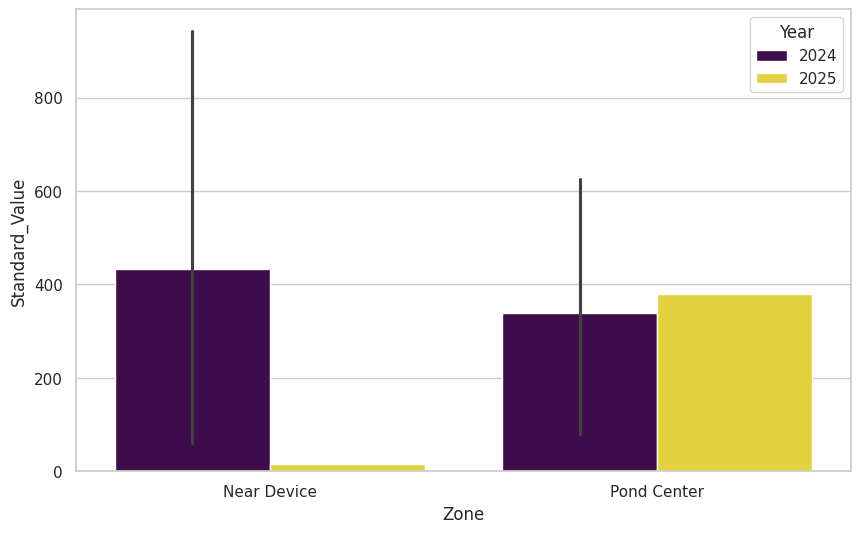

In [ ]:
df = df_clean.copy()
sns.set_theme(style="whitegrid")

# Total Phosphorus by Zone and Year
plt.figure(figsize=(10, 6))
tp_plot = sns.barplot(
    data=df[df['Parameter'] == 'Total Phosphorus'],
    x='Zone',
    y='Standard_Value',
    hue='Year',
    palette='viridis'
)


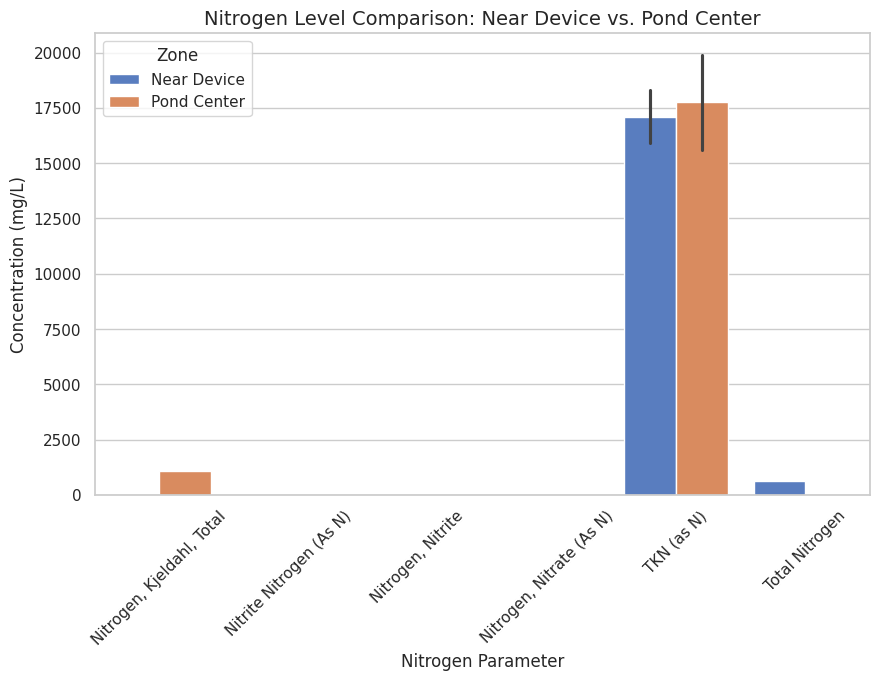

In [ ]:
# Nitrogen comparison: Near Device vs Pond Center
plt.figure(figsize=(10, 6))
nitrogen_df = df[df['Parameter'].str.contains('Nitrogen|TKN', case=False)]
zones_of_interest = nitrogen_df[nitrogen_df['Zone'].isin(['Near Device', 'Pond Center'])]

sns.barplot(
    data=zones_of_interest,
    x='Parameter',
    y='Standard_Value',
    hue='Zone',
    palette='muted'
)

plt.title('Nitrogen Level Comparison: Near Device vs. Pond Center', fontsize=14)
plt.ylabel('Concentration (mg/L)')
plt.xlabel('Nitrogen Parameter')
plt.xticks(rotation=45)
plt.show()

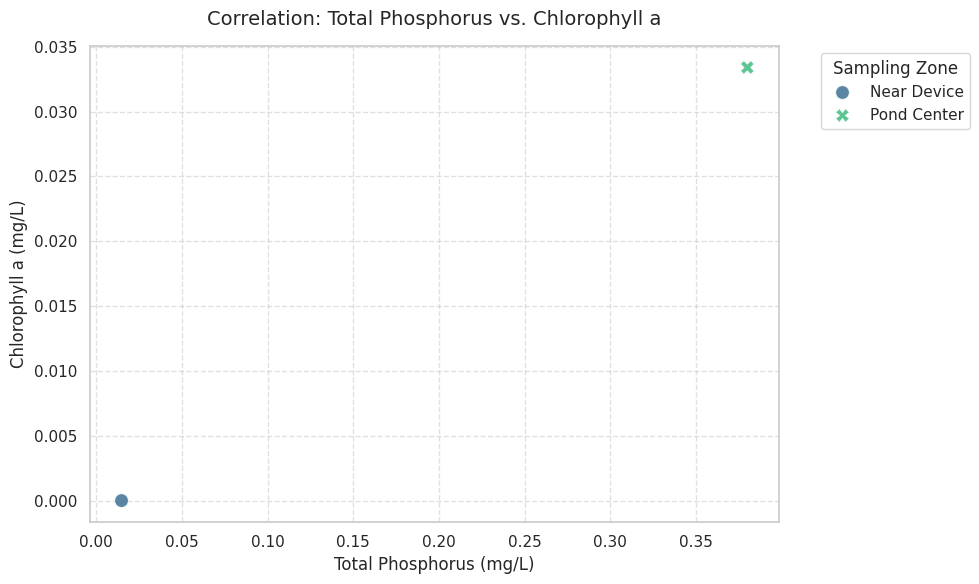

In [ ]:
# Note: Chlorophyll-a only available in 2025 samples — scatter limited to 2025 data
params_to_plot = ['Total Phosphorus', 'Chlorophyll A']
df_filtered = df[df['Parameter'].isin(params_to_plot)].copy()

df_pivot = df_filtered.pivot_table(
    index=['Sampling Date', 'Zone', 'Year'],
    columns='Parameter',
    values='Standard_Value'
).reset_index()

df_pivot['Total_Phosphorus_mgL'] = df_pivot['Total Phosphorus'] / 1000
df_pivot['Chlorophyll_a_mgL'] = df_pivot['Chlorophyll A'] / 1000

plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=df_pivot,
    x='Total_Phosphorus_mgL',
    y='Chlorophyll_a_mgL',
    hue='Zone',
    style='Zone',
    s=100,
    alpha=0.8,
    palette='viridis'
)

plt.title('Correlation: Total Phosphorus vs. Chlorophyll a', fontsize=14, pad=15)
plt.xlabel('Total Phosphorus (mg/L)', fontsize=12)
plt.ylabel('Chlorophyll a (mg/L)', fontsize=12)
plt.legend(title='Sampling Zone', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
#uploading to github manually
# output_path = "capstone_Chrysler_Pond/Sample_results_2024_2025.csv"
# df_clean.to_csv(output_path, index=False)
# print(f"DataFrame saved to {output_path}")